# RB and spikes coocurrance

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
from functions_plotting import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_band_project/dataframes' ### here the resulting dataframes will be saved
MONKEY_LIST = ['L','N','F'] #,'A']
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']
AREAS = params_analysis['areas']

AREA = 'V12'
SEL_TH = params_analysis['select_th']
DUAL_TH = [2.5,3.5]

## Functions

In [16]:
def corr_list_one_arr(env_arr,spikes_arr,bin_size=10,num_bins_win=100):
    """
    Return list of Pearson corr. values for 1 s windows.
    The input is an array, which is further summed up, binned, and correlation is computed on windows of num_bins_win.
    """
    env_tot = np.sum(env_arr,axis=0)
    sp_tot = np.sum(spikes_arr,axis=0)
    len_rec_ms = env_tot.shape[0]
    len_rec_s = int(len_rec_ms//1000)
    # cutting out the right side that does not fit into bins
    env_tot = env_tot[:len_rec_s*1000]
    sp_tot = sp_tot[:len_rec_s*1000]
    #print(env_tot.shape)
    # binning
    env_tot = env_tot.reshape(-1, bin_size).sum(axis=1)
    sp_tot = sp_tot.reshape(-1, bin_size).sum(axis=1)
    #print(env_tot.shape)
    corr_list = []
    for i in range(len_rec_s):
        r, _ = pearsonr(env_tot[i*num_bins_win:(i+1)*num_bins_win],sp_tot[i*num_bins_win:(i+1)*num_bins_win])
        corr_list.append(r) 
    return corr_list

In [11]:
def moving_average(data, window_size):
    """
    
    """
    window = np.ones(np.int64(window_size))/float(window_size)
    return np.convolve(data, window, mode='same')

In [12]:
def plot_example_activity(env_arr,spikes_arr,cl_arr,set_params={}):
    """
    TODO
    """
    #sigma_spikes = set_params['sigma_spikes']
    #sigma_env = set_params['sigma_env']
    win_spikes = set_params['moving_win_width']
    win_env = set_params['moving_win_width']
    cell_classes = set_params['final_classes']
    class_color = set_params['class_colors']

    sp_dict = {}
    for cl in cell_classes:
        cl_mask = cl_arr==cl
        #print(f'Num. cells {cl}: {np.sum(cl_mask)}')
        sp_dict[cl] = np.sum(spikes_arr[cl_mask],axis=0)
        if win_spikes is not None:  # smoothing
            sp_dict[cl] = moving_average(sp_dict[cl],win_spikes)
        sp_dict[cl] = (sp_dict[cl]-np.min(sp_dict[cl]))/(np.max(sp_dict[cl])-np.min(sp_dict[cl]))  # normalisation

    spikes_total = np.sum(spikes_arr,axis=0)
    env_total = np.sum(env_arr,axis=0)
    if win_env is not None:
        env_total = moving_average(env_total,win_env)
    env_total =  (env_total-np.min(env_total))/(np.max(env_total)-np.min(env_total))
    if win_spikes is not None:
        spikes_total = moving_average(spikes_total,win_spikes)
    spikes_total =  (spikes_total-np.min(spikes_total))/(np.max(spikes_total)-np.min(spikes_total))
    
    fig, ax = plt.subplots()
    fig.set_figwidth(10)
    fig.set_figheight(6)

    N=250
    x_pos = range(len(env_total))
    # TOTAL ACTIVITY
    ax.plot(x_pos[N:-N],env_total[N:-N]*1.8,alpha=0.6,color='k',label='Total RB env.')
    ax.plot(x_pos[N:-N],spikes_total[N:-N]*1.8,alpha=0.7,color='purple',label='Total num. spikes')
    
    # INIDIVIDUAL CLASSES ACTIVITY
    shift = -1
    norm_factor = 0.6
    for idx, cl in enumerate(cell_classes):
        ax.fill_between(x_pos[N:-N],shift,sp_dict[cl][N:-N]*norm_factor+shift,color=CLASS_COLORS[cl],alpha=0.3)
        ax.plot(x_pos[N:-N],sp_dict[cl][N:-N]*norm_factor+shift,color=CLASS_COLORS[cl],alpha=0.9)
        shift-=0.8

    for sp in ['top','right','left']:
        ax.spines[sp].set_visible(False)
    ax.set_yticks([])

    xticks_ms = ax.get_xticks()
    xticks_s = xticks_ms/1000
    ax.set_xticks(xticks_ms)
    ax.set_xticklabels([f'{x:.1f}' for x in xticks_s])

    ax.set_xlabel('Time [s]')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()
    plt.close()
    return

In [28]:
def find_close_triplets(nums, low_threshold = 7, hi_threshold=12):
    """
    Auxiliary function for finding repeating spiking.
    """
    result_triplet = []
    result_leader = []
    for i in range(len(nums) - 2):
        if (low_threshold < nums[i+1] - nums[i] and
            nums[i+1] - nums[i] < hi_threshold and 
            low_threshold < nums[i+2] - nums[i+1] and 
            nums[i+2] - nums[i+1] < hi_threshold):
            result_triplet.append((nums[i], nums[i+1], nums[i+2]))
            result_leader.append(nums[i])
    return result_triplet, result_leader

## Plotting - illustration of activity, ripples and spikes of different types

### Data loading

In [4]:
# Example for monkey L
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]

In [5]:
# Ripple band envelope
arr_list = []
for arr in range(16):
    if AREAS[MONKEY][arr] in ['V1','V2']:
        print(arr)
        aux_bl = load_block(MONKEY,arr+1,'RS','RB',DATE,data_folder=DATA_FOLDER)
        aux_env = sig_block_to_arr(aux_bl,'RB_envelope_norm')
        # Additional lowpass filter
        aux_env = elephant.signal_processing.butter(aux_env, highpass_frequency=None, lowpass_frequency=40, 
                                                    order=6, filter_function='sosfiltfilt',sampling_frequency=1000, axis=-1)
        # renormalize, because we filtered again
        aux_env = aux_env/aux_env.std(axis=1,keepdims=True)
        arr_list.append(aux_env)

0
3
4
5
6
7
8
9
10
11
12
13
14
15


In [6]:
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)

In [7]:
# Spikes
sp_arr_list = []
cl_list = []
for arr in range(16):
    if AREAS[MONKEY][arr] in ['V1','V2']:
        print(arr)
        aux_bl = load_block(MONKEY,arr+1,'RS','spikes',DATE,data_folder=DATA_FOLDER)
        aux_arr = spike_block_to_arr(aux_bl)
        sp_arr_list.append(aux_arr)
        cl_list.append(np.array(find_classes_cells(aux_bl,df_sua)))

0
3
4
5
6
7
8
9
10
11
12
13
14
15


### Plotting

In [8]:
# pooling data from all arrays in V1
env_arr = np.vstack(arr_list)
cl_arr = np.vstack(cl_list)[:,0]
spikes_arr = np.vstack(sp_arr_list)

In [13]:
set_params = {}
#set_params['sigma_spikes'] = 50
#set_params['sigma_env'] = 10
set_params['moving_win_width'] = 100
set_params['final_classes'] = FINAL_CLASSES
set_params['class_colors'] = CLASS_COLORS

In [14]:
WIN_WIDTH = 15*1000

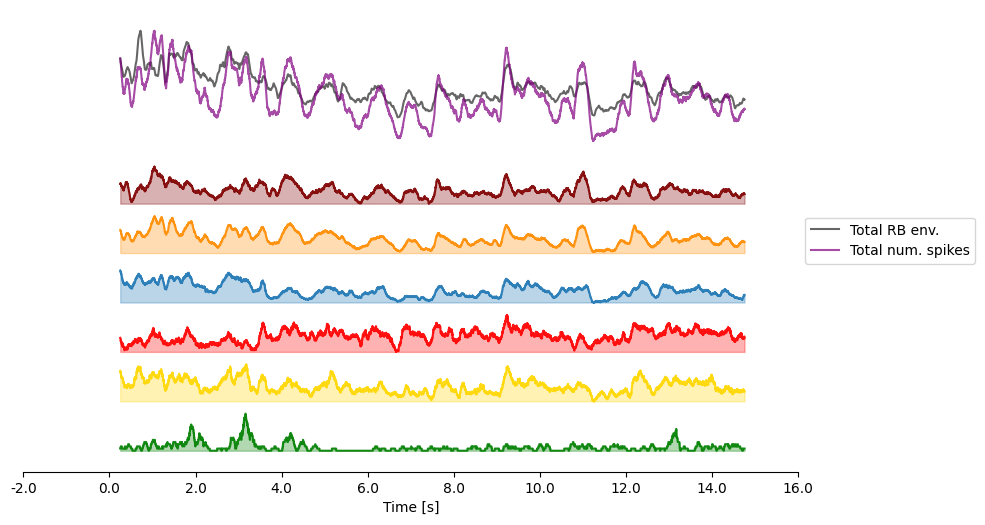

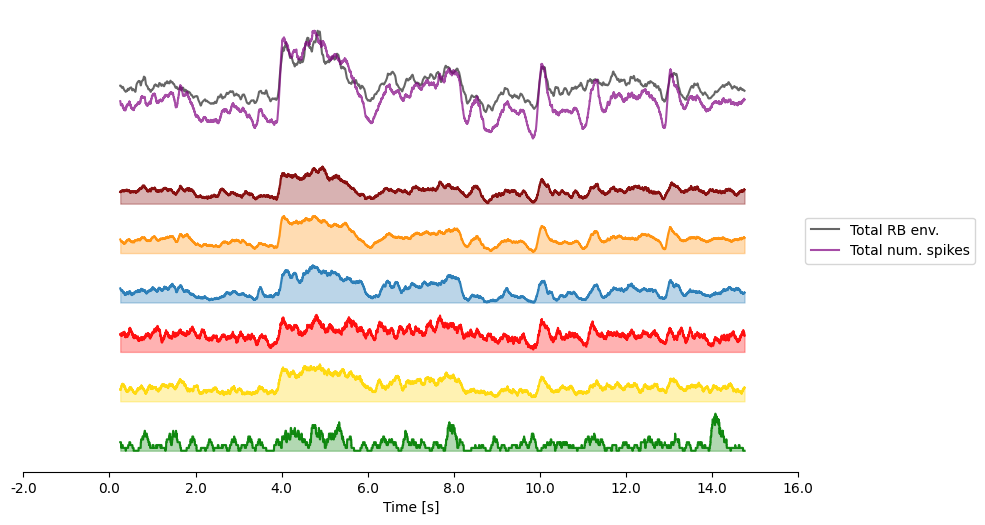

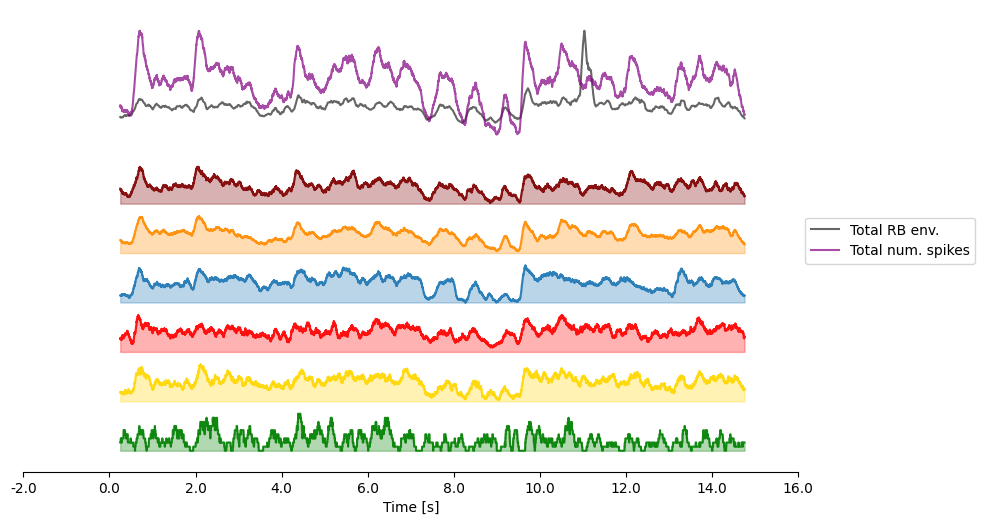

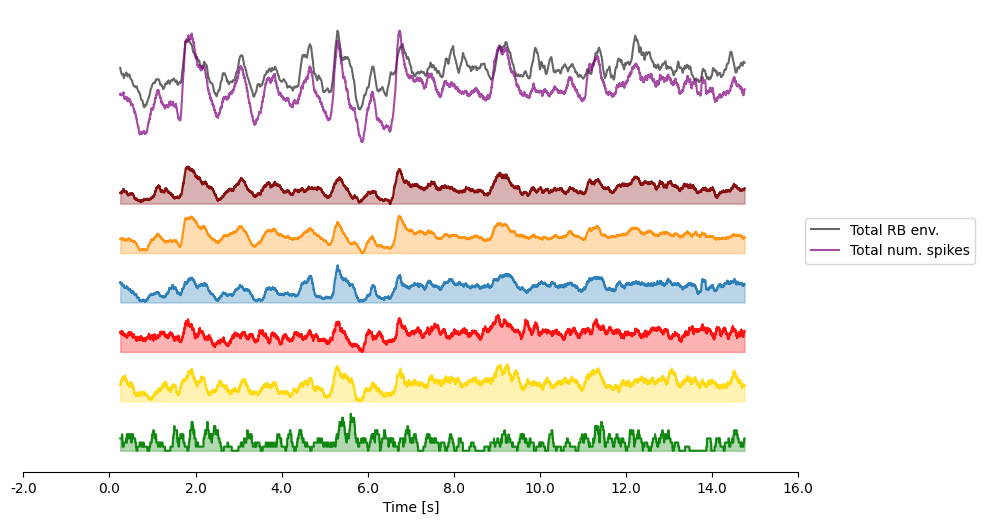

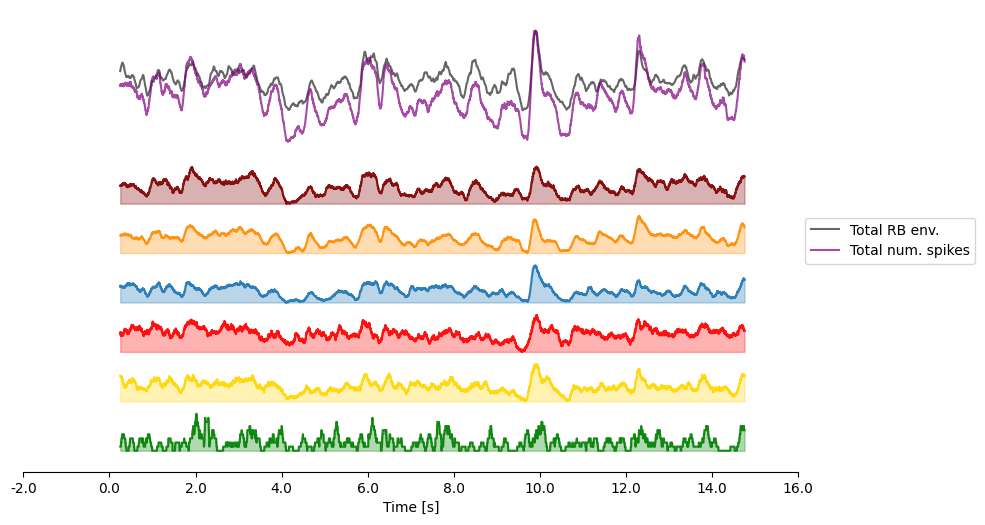

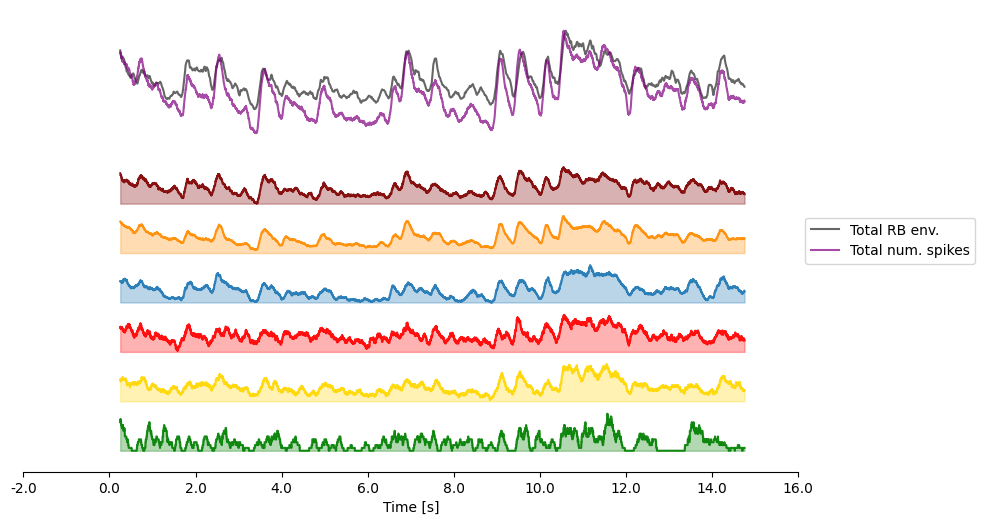

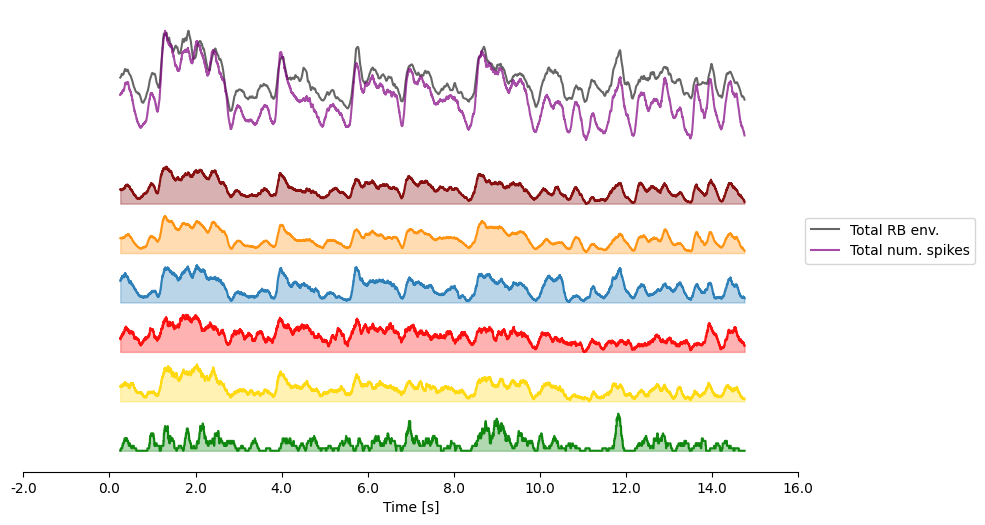

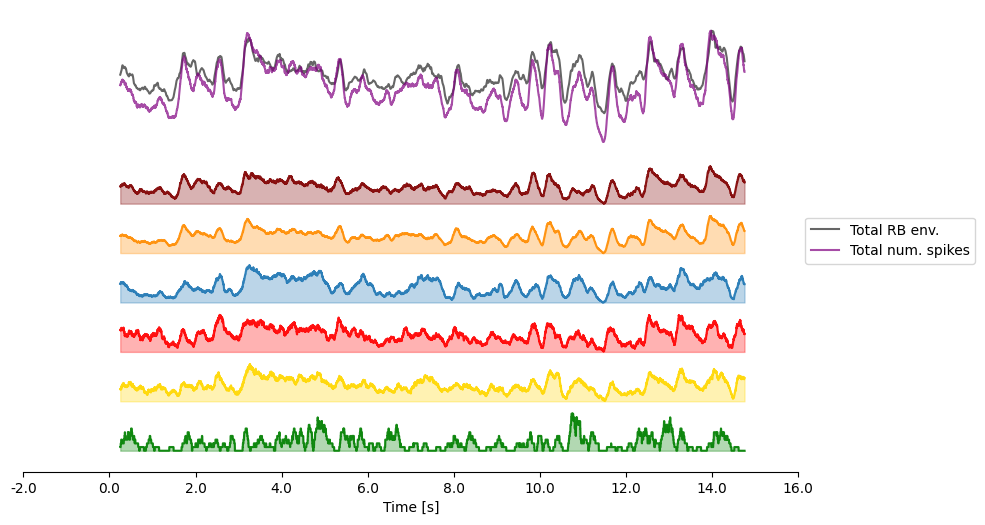

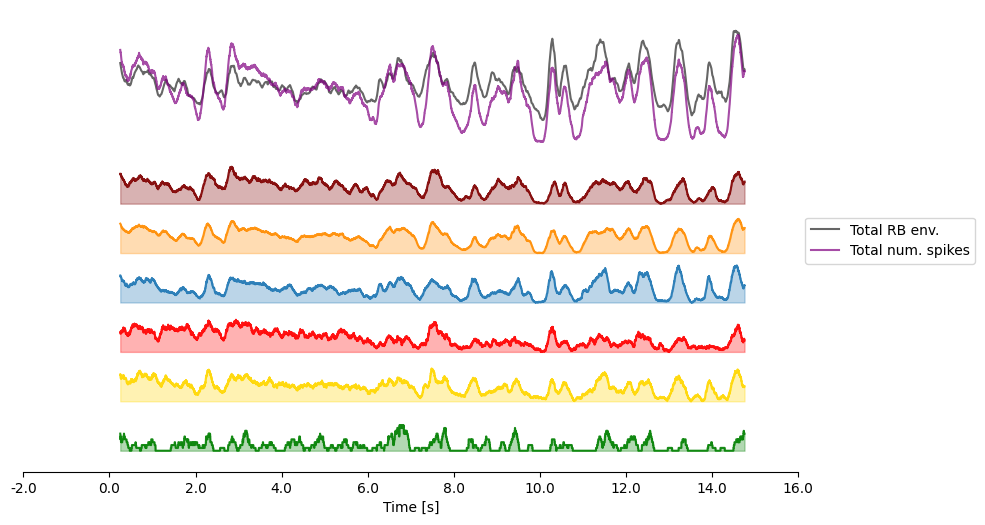

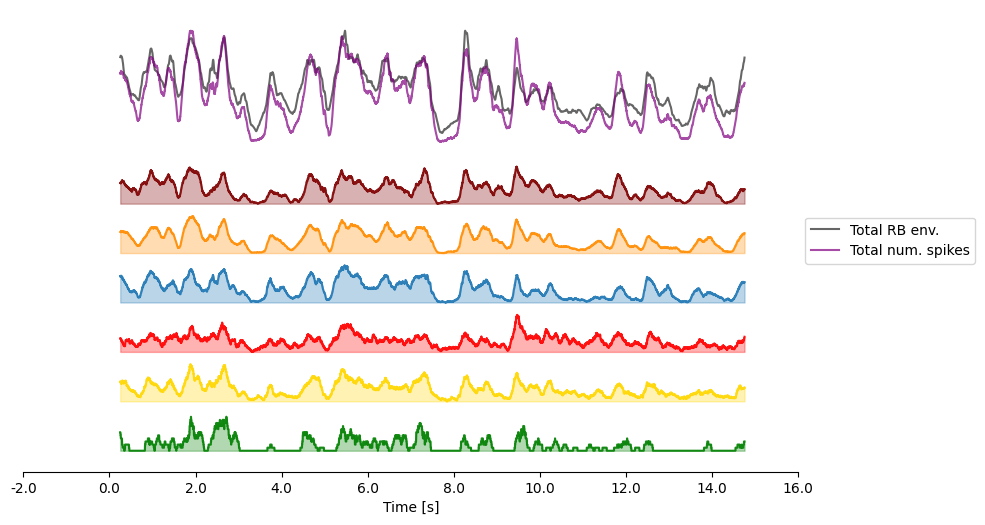

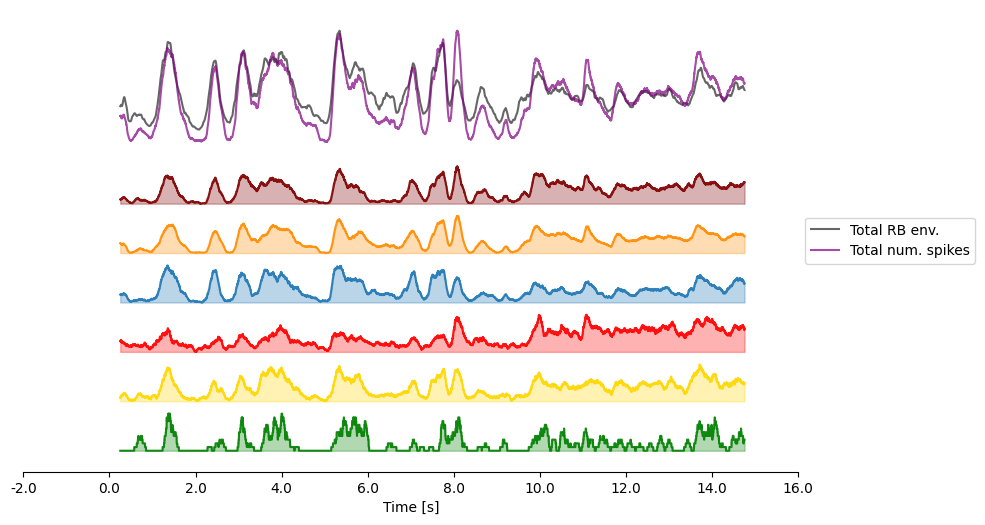

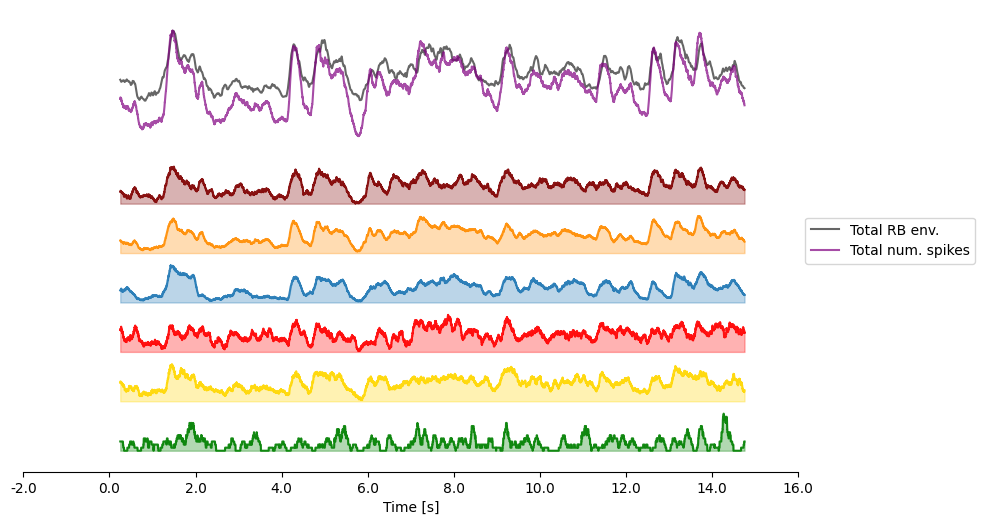

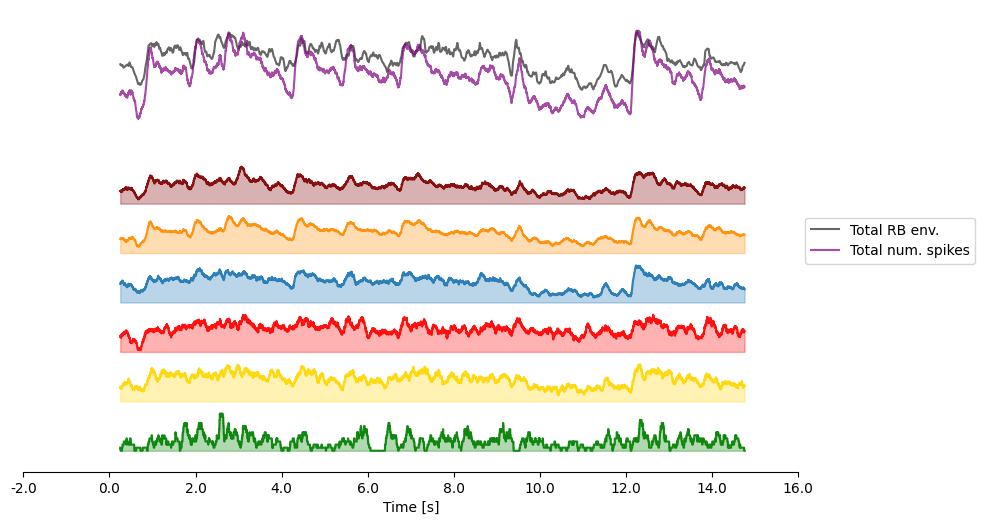

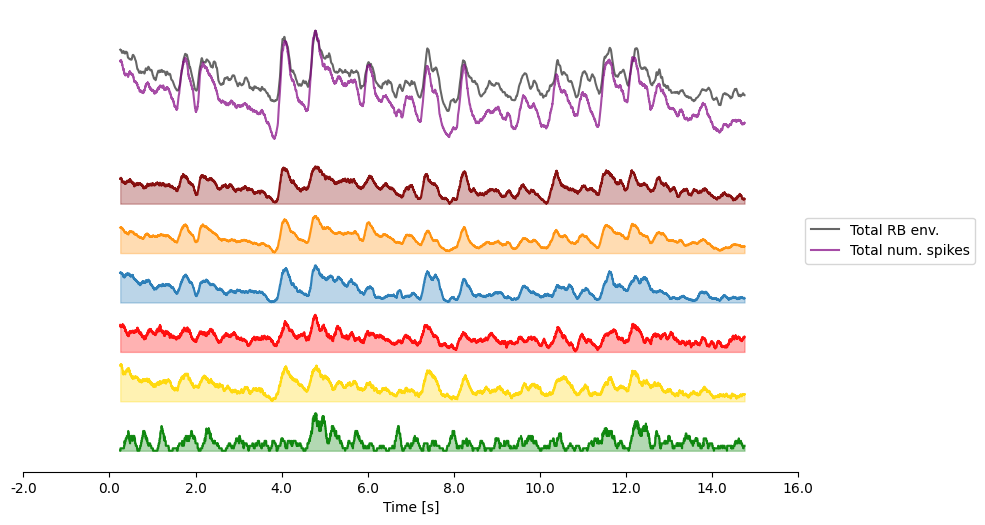

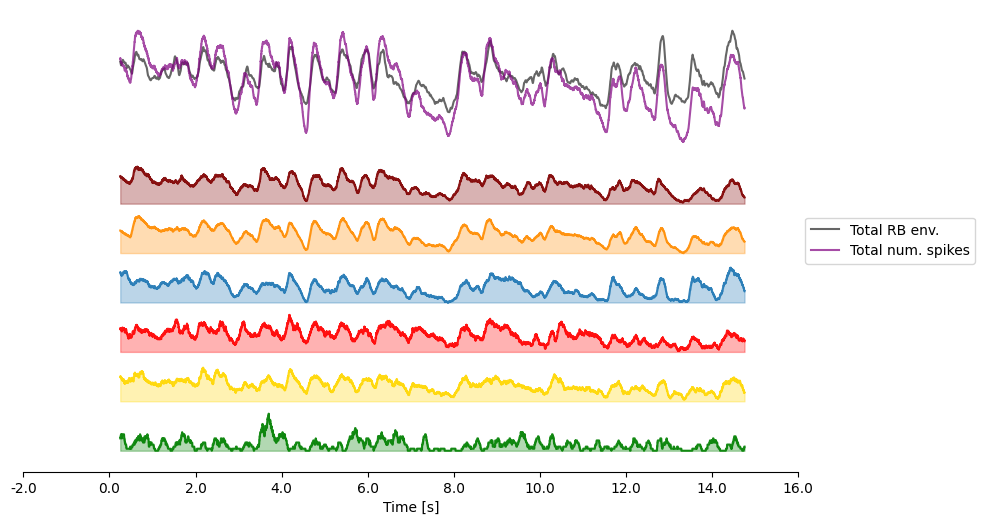

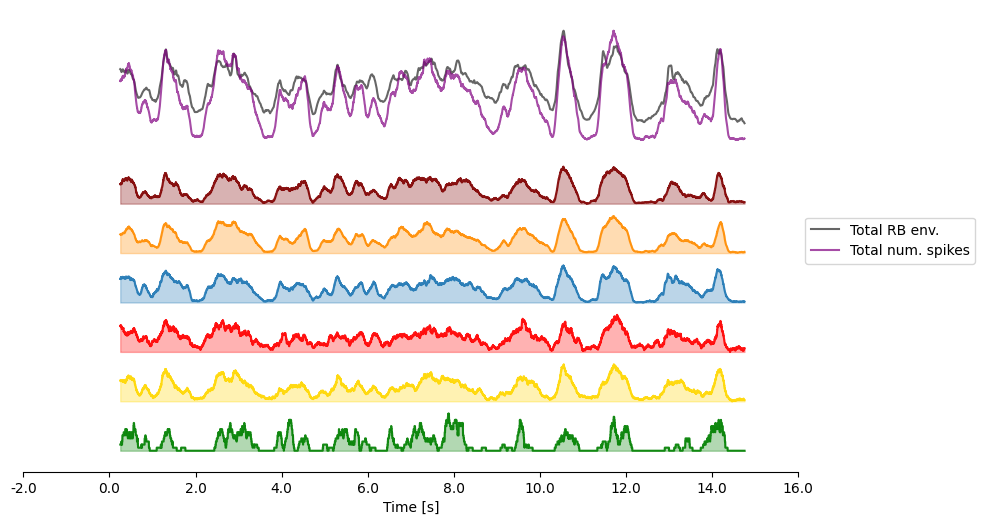

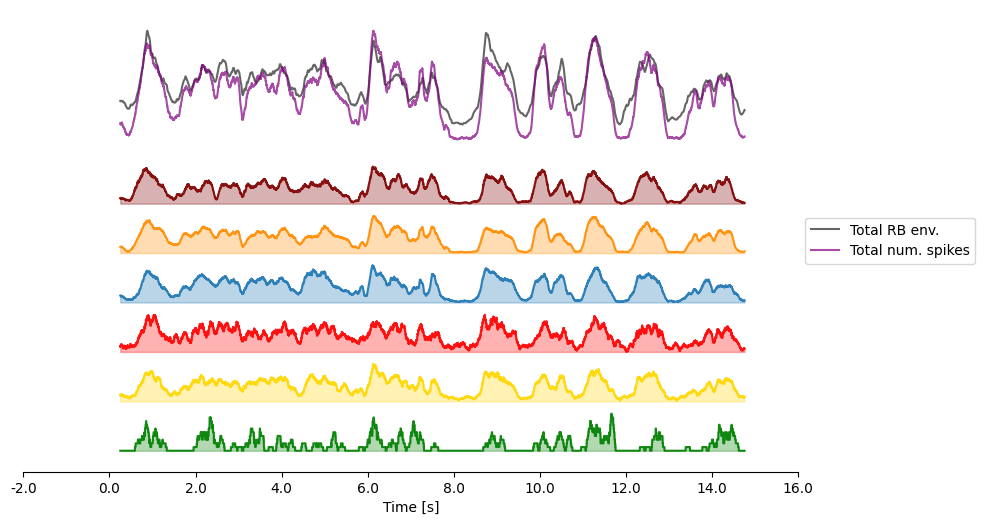

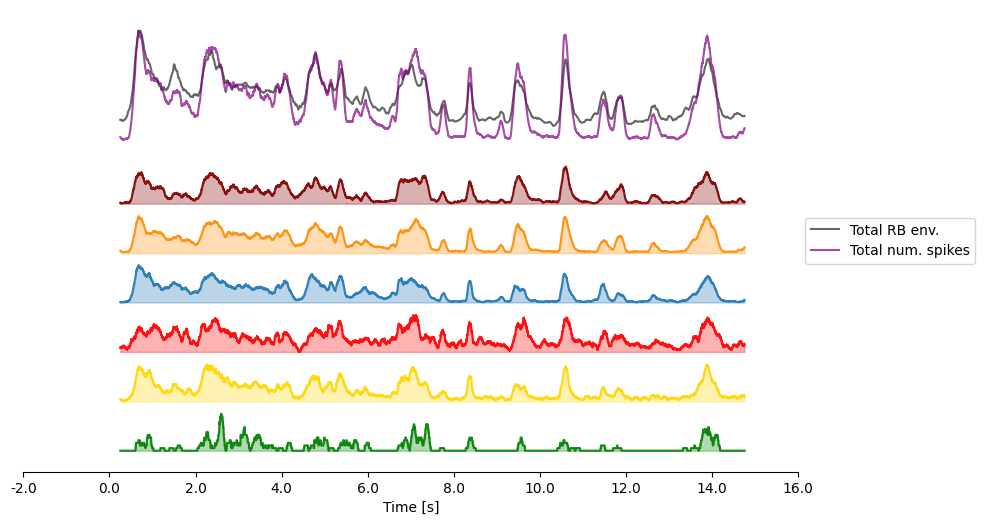

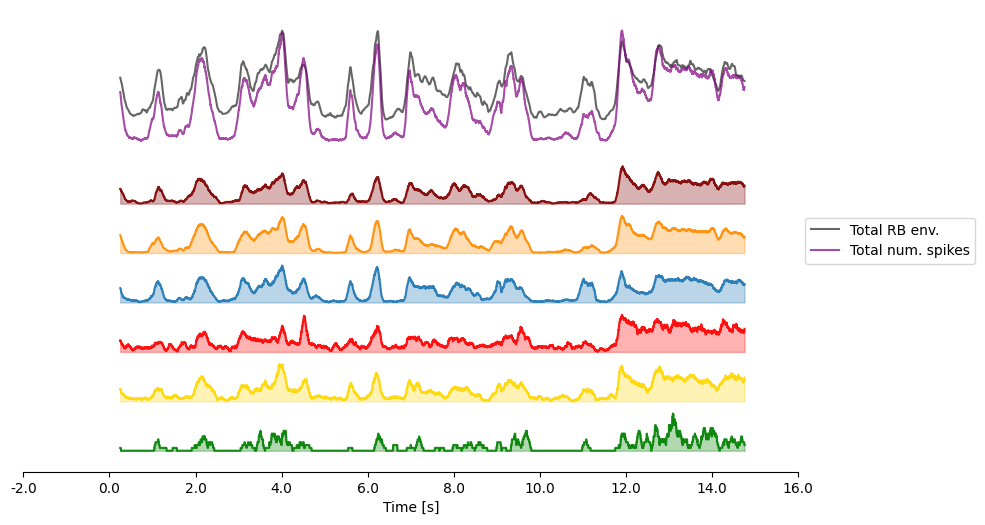

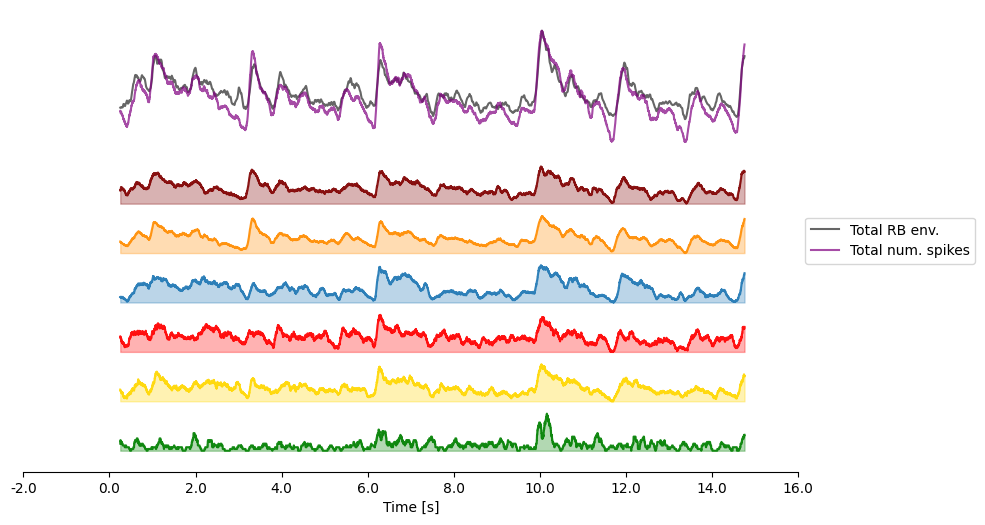

In [15]:
for i in range(20):
    start_idx = i*WIN_WIDTH
    stop_idx = (i+1)*WIN_WIDTH
    plot_example_activity(env_arr[:,start_idx:stop_idx],spikes_arr[:,start_idx:stop_idx],cl_arr,set_params)

## Correlation RB env. and spikes

In [17]:
EC_all_corr_lists = []
EO_all_corr_lists = []
for monkey in MONKEY_LIST:
    print(monkey)
    for date in DATES[monkey]['RS']:
        print(date)
        for arr in range(1,17):
            try:
                if AREAS[monkey][arr-1] in ['V1','V2']:
                    print(arr)
                    # RB envelope
                    aux_bl = load_block(monkey,arr,'RS','RB',date,data_folder=DATA_FOLDER)
                    aux_env = sig_block_to_arr(aux_bl,'RB_envelope_norm')
                    t_start_arr = np.int64(aux_bl.segments[0].t_start)
                    aux_env = elephant.signal_processing.butter(aux_env, highpass_frequency=None, lowpass_frequency=40, 
                                                        order=6, filter_function='sosfiltfilt',sampling_frequency=1000, axis=-1)
                    # renormalize, because we filtered again
                    aux_env = aux_env/aux_env.std(axis=1,keepdims=True)
                    # EC and EO
                    file_path = f'/CSNG/studekat/ripple_band_project/metadata/EC_EO_indicators/eyes_indic_monkey_{monkey}_RS_date_{date}_common_times.pkl'
                    with open(file_path, 'rb') as file:
                        eyes_dict = pickle.load(file)
                    aux_env = cut_abs_times(aux_env,t_start_arr,monkey,rec_type='RS',date=date,params=params_analysis)
                    # spikes
                    aux_bl = load_block(monkey,arr,'RS','spikes',date,data_folder=DATA_FOLDER)
                    aux_sp_arr = spike_block_to_arr(aux_bl)
                    aux_sp_arr = cut_abs_times(aux_sp_arr,t_start_arr,monkey,rec_type='RS',date=date,params=params_analysis)
                    # eyes masks
                    EC_mask = eyes_dict['EC'].astype(bool)
                    EO_mask = eyes_dict['EO'].astype(bool)
                    #print([EC_mask.shape[0],aux_env.shape[1],aux_sp_arr.shape[1]])
                    min_len = np.min([EC_mask.shape[0],aux_env.shape[1],aux_sp_arr.shape[1]])
                    # cutting away 1 ms differences that sometimes occur
                    EC_mask = EC_mask[:min_len]
                    EO_mask = EO_mask[:min_len]
                    aux_env = aux_env[:,:min_len]
                    aux_sp_arr = aux_sp_arr[:,:min_len]
                    # correlation list EC
                    aux_corr_list = corr_list_one_arr(aux_env[:,EC_mask],aux_sp_arr[:,EC_mask],bin_size=10,num_bins_win=100)
                    EC_all_corr_lists.append(aux_corr_list)
                    aux_corr_list = corr_list_one_arr(aux_env[:,EO_mask],aux_sp_arr[:,EO_mask],bin_size=10,num_bins_win=100)
                    EO_all_corr_lists.append(aux_corr_list)  
            except:
                print(f'For array {arr} the data were not processed.')

L
20170725
1
4
5
6
7
8
9
10
11
12
13
14
15
16
20170809
1
4
5
6


/home/studekat/virt_env/work/lib/python3.12/site-packages/elephant/conversion.py:1130: UserWarning: Binning discarded 1 last spike(s) of the input spiketrain
  warnings.warn("Binning discarded {} last spike(s) of the "


7
8
9
10
11
12
13
14
15
16
20170810
1
4
5
6
7
8
9
10
11
12
13
14
15
16
N
20240719_B1
1
2
3
4
5
/CSNG/Ephys_data/Macaque_data/macaqueN_RS_20240719_B1/RB/macaqueN_RS_20240719_B1_Array5_RB.nix
For array 5 the data were not processed.
6
7
8
20240719_B2
1
2
3
4
5
/CSNG/Ephys_data/Macaque_data/macaqueN_RS_20240719_B2/RB/macaqueN_RS_20240719_B2_Array5_RB.nix
For array 5 the data were not processed.
6
7
8
F
20240122_B1
1
2
3
4
5
6
7
8
16


/home/studekat/virt_env/work/lib/python3.12/site-packages/elephant/conversion.py:1130: UserWarning: Binning discarded 2 last spike(s) of the input spiketrain
  warnings.warn("Binning discarded {} last spike(s) of the "


20241216_B1
1
2
3
4
5
6
7
8
16


In [18]:
EO_all_corr = np.array(list_merge(EO_all_corr_lists))
EC_all_corr = np.array(list_merge(EC_all_corr_lists))

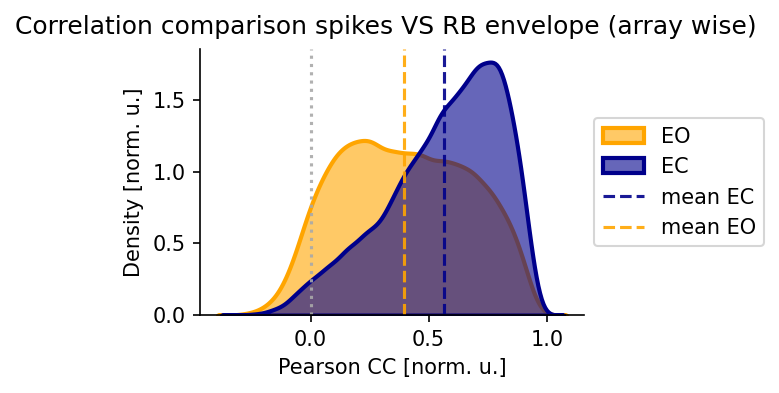

In [19]:
fig, ax = plt.subplots(dpi=150)
fig.set_figwidth(3.3)
fig.set_figheight(2.3)

plt.suptitle('Correlation comparison spikes VS RB envelope (array wise)')

sns.kdeplot(EO_all_corr, ax=ax, fill=True, color='orange', linewidth=2,alpha=0.6,label='EO')
sns.kdeplot(EC_all_corr, ax=ax, fill=True, color='darkblue', linewidth=2,alpha=0.6,label='EC')
ax.axvline(np.mean(EC_all_corr),color='darkblue',ls='dashed',alpha=0.9,label='mean EC')
ax.axvline(np.mean(EO_all_corr),color='orange',ls='dashed',alpha=0.9,label='mean EO')
ax.axvline(0,alpha=0.9,color='darkgray',ls=':')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Density [norm. u.]')
ax.set_xlabel('Pearson CC [norm. u.]')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()
plt.close()

## Examples of phase locked transient spiking 

### Red 1

In [66]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 6
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 1
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170725
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_narrow_sharp
3 DOWN_narrow_sharp
4 DOWN_narrow_sharp
5 DOWN_narrow_sharp
6 DOWN_narrow_sharp
7 DOWN_narrow_sharp
8 DOWN_narrow_sharp
9 DOWN_medium_shallow
10 DOWN_medium_shallow
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_narrow_shallow
19 DOWN_narrow_shallow
20 DOWN_medium_shallow
21 DOWN_medium_shallow
22 DOWN_medium_shallow
23 DOWN_medium_shallow
24 DOWN_medium_shallow
Num. cells: 25
Cell idx: 1, DOWN_narrow_sharp, channel: 14


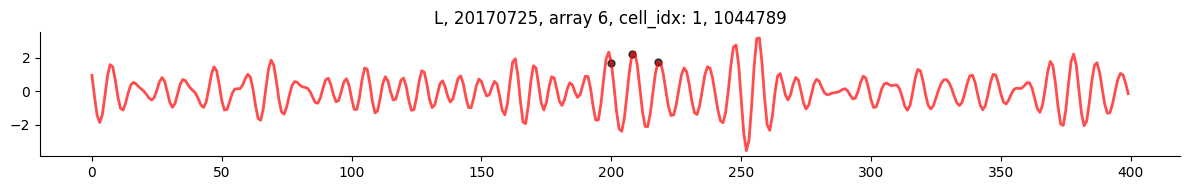

In [67]:
for spike in spikes_leading:
    if spike==1044789:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Red 2

In [68]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 6
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 3
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170725
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_narrow_sharp
3 DOWN_narrow_sharp
4 DOWN_narrow_sharp
5 DOWN_narrow_sharp
6 DOWN_narrow_sharp
7 DOWN_narrow_sharp
8 DOWN_narrow_sharp
9 DOWN_medium_shallow
10 DOWN_medium_shallow
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_narrow_shallow
19 DOWN_narrow_shallow
20 DOWN_medium_shallow
21 DOWN_medium_shallow
22 DOWN_medium_shallow
23 DOWN_medium_shallow
24 DOWN_medium_shallow
Num. cells: 25
Cell idx: 3, DOWN_narrow_sharp, channel: 15


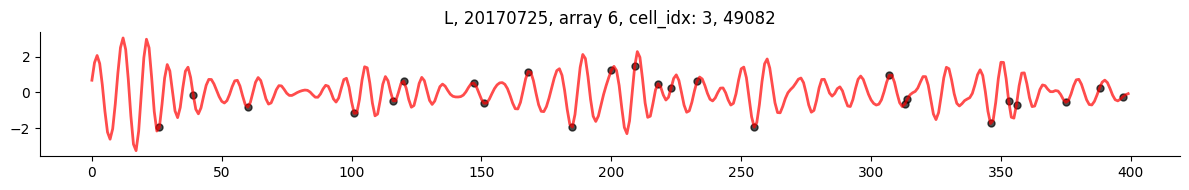

In [69]:
for spike in spikes_leading:
    if spike==49082:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        if shift>0:
            mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
            spikes_cut = spike_idx[mask]
            plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
        
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            plt.tight_layout()
            plt.show()
            plt.close()

### Blue 1

In [70]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 14
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 5
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170725
V1
0 DOWN_narrow_shallow
1 DOWN_medium_shallow
2 DOWN_medium_shallow
3 DOWN_medium_shallow
4 DOWN_medium_shallow
5 DOWN_wide
6 DOWN_wide
7 DOWN_medium_sharp
8 DOWN_medium_shallow
9 DOWN_wide
10 DOWN_wide
11 DOWN_wide
12 DOWN_medium_shallow
13 DOWN_wide
14 DOWN_wide
15 DOWN_wide
16 DOWN_wide
17 DOWN_wide
18 DOWN_wide
19 DOWN_medium_shallow
20 DOWN_medium_sharp
21 DOWN_wide
22 DOWN_wide
23 DOWN_wide
24 DOWN_wide
25 DOWN_wide
26 DOWN_wide
27 DOWN_medium_shallow
28 DOWN_wide
29 DOWN_wide
30 DOWN_wide
31 DOWN_narrow_shallow
Num. cells: 32
Cell idx: 5, DOWN_wide, channel: 19


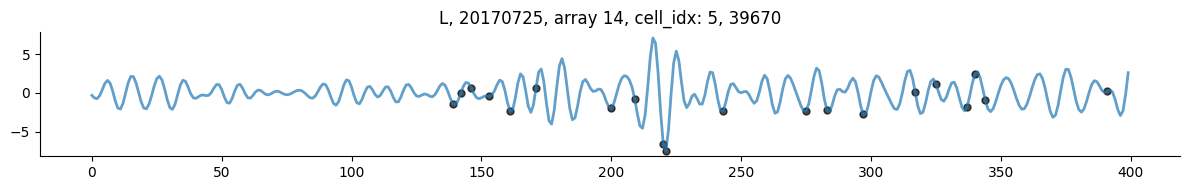

In [71]:
for spike in spikes_leading:
    if spike==39670:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Blue 2

In [72]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 7
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170725
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_medium_sharp
3 DOWN_medium_sharp
4 DOWN_medium_sharp
5 DOWN_medium_sharp
6 DOWN_wide
7 DOWN_wide
8 DOWN_wide
9 UP
10 DOWN_medium_sharp
11 DOWN_medium_sharp
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_narrow_sharp
19 DOWN_wide
20 DOWN_medium_sharp
21 DOWN_narrow_sharp
22 DOWN_wide
23 DOWN_medium_sharp
24 DOWN_wide
25 DOWN_narrow_sharp
26 DOWN_narrow_sharp
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
Num. cells: 31
Cell idx: 7, DOWN_wide, channel: 19


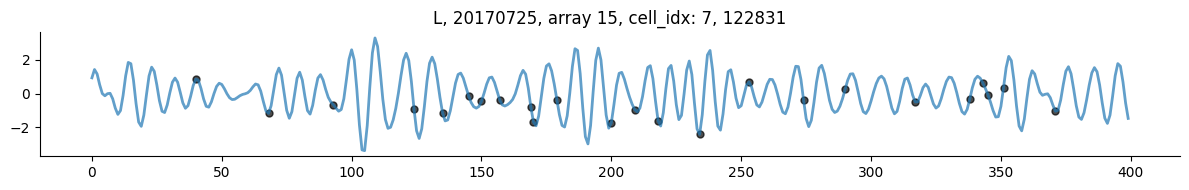

In [74]:
for spike in spikes_leading:
    if spike==122831:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Yellow 1

In [75]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 3
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170725
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_medium_sharp
3 DOWN_medium_sharp
4 DOWN_medium_sharp
5 DOWN_medium_sharp
6 DOWN_wide
7 DOWN_wide
8 DOWN_wide
9 UP
10 DOWN_medium_sharp
11 DOWN_medium_sharp
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_narrow_sharp
19 DOWN_wide
20 DOWN_medium_sharp
21 DOWN_narrow_sharp
22 DOWN_wide
23 DOWN_medium_sharp
24 DOWN_wide
25 DOWN_narrow_sharp
26 DOWN_narrow_sharp
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
Num. cells: 31
Cell idx: 3, DOWN_medium_sharp, channel: 15


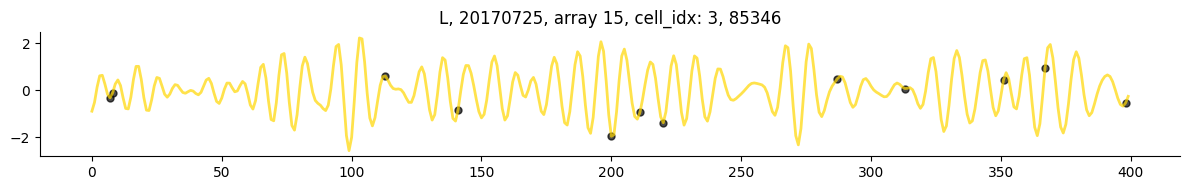

In [76]:
for spike in spikes_leading:
    if spike==85346:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Yellow 2

In [77]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 4
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 29
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170809
V1
0 DOWN_narrow_sharp
1 DOWN_medium_sharp
2 DOWN_wide
3 DOWN_wide
4 DOWN_medium_shallow
5 DOWN_medium_sharp
6 DOWN_medium_sharp
7 DOWN_medium_sharp
8 DOWN_medium_sharp
9 DOWN_medium_shallow
10 UP
11 DOWN_narrow_sharp
12 DOWN_wide
13 DOWN_narrow_sharp
14 DOWN_medium_sharp
15 DOWN_medium_sharp
16 DOWN_medium_sharp
17 DOWN_medium_sharp
18 DOWN_wide
19 DOWN_narrow_sharp
20 DOWN_medium_sharp
21 DOWN_narrow_sharp
22 DOWN_medium_sharp
23 DOWN_medium_shallow
24 DOWN_medium_sharp
25 DOWN_narrow_sharp
26 DOWN_medium_sharp
27 DOWN_narrow_sharp
28 DOWN_medium_shallow
29 DOWN_medium_sharp
30 DOWN_medium_sharp
31 DOWN_medium_sharp
32 DOWN_medium_shallow
33 DOWN_medium_shallow
34 DOWN_narrow_shallow
35 DOWN_medium_shallow
36 DOWN_medium_shallow
37 DOWN_wide
38 DOWN_medium_shallow
Num. cells: 39
Cell idx: 29, DOWN_medium_sharp, channel: 45


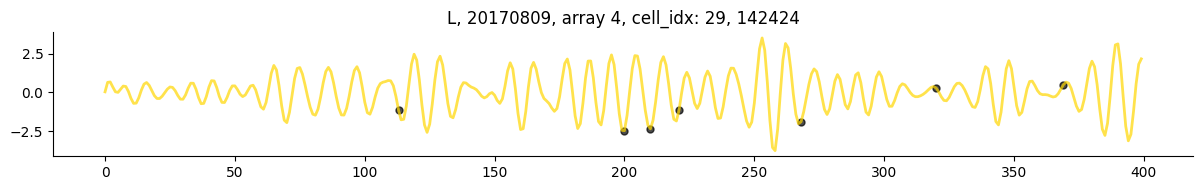

In [78]:
for spike in spikes_leading:
    if spike==142424:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Maroon 1

In [79]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 7
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 1
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170809
V1
0 DOWN_narrow_shallow
1 DOWN_narrow_shallow
2 DOWN_medium_shallow
3 DOWN_medium_shallow
4 DOWN_medium_shallow
5 DOWN_medium_shallow
6 DOWN_narrow_shallow
7 DOWN_medium_sharp
8 DOWN_wide
9 DOWN_narrow_sharp
10 DOWN_wide
11 DOWN_wide
12 DOWN_narrow_sharp
13 DOWN_wide
14 DOWN_medium_shallow
15 DOWN_narrow_sharp
16 DOWN_narrow_shallow
17 DOWN_medium_shallow
18 DOWN_medium_shallow
19 DOWN_narrow_shallow
20 DOWN_medium_shallow
21 DOWN_wide
22 DOWN_wide
23 DOWN_narrow_shallow
24 DOWN_wide
25 DOWN_medium_shallow
26 DOWN_wide
27 DOWN_wide
28 DOWN_medium_shallow
Num. cells: 29
Cell idx: 1, DOWN_narrow_shallow, channel: 11


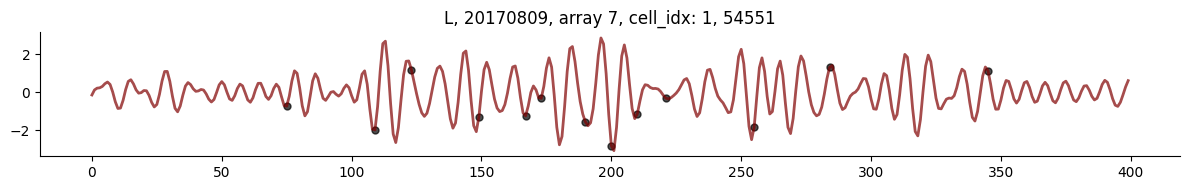

In [80]:
for spike in spikes_leading:
    if spike==54551:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Maroon 2

In [81]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 7
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 0
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170809
V1
0 DOWN_narrow_shallow
1 DOWN_narrow_shallow
2 DOWN_medium_shallow
3 DOWN_medium_shallow
4 DOWN_medium_shallow
5 DOWN_medium_shallow
6 DOWN_narrow_shallow
7 DOWN_medium_sharp
8 DOWN_wide
9 DOWN_narrow_sharp
10 DOWN_wide
11 DOWN_wide
12 DOWN_narrow_sharp
13 DOWN_wide
14 DOWN_medium_shallow
15 DOWN_narrow_sharp
16 DOWN_narrow_shallow
17 DOWN_medium_shallow
18 DOWN_medium_shallow
19 DOWN_narrow_shallow
20 DOWN_medium_shallow
21 DOWN_wide
22 DOWN_wide
23 DOWN_narrow_shallow
24 DOWN_wide
25 DOWN_medium_shallow
26 DOWN_wide
27 DOWN_wide
28 DOWN_medium_shallow
Num. cells: 29
Cell idx: 0, DOWN_narrow_shallow, channel: 3


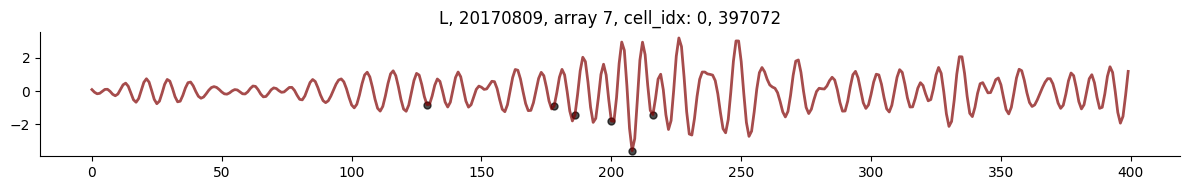

In [82]:
for spike in spikes_leading:
    if spike==397072:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Green 1

In [83]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 5
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 4
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170809
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_medium_shallow
3 DOWN_narrow_sharp
4 UP
5 DOWN_wide
6 DOWN_medium_shallow
7 DOWN_medium_shallow
8 DOWN_medium_sharp
9 DOWN_medium_shallow
10 DOWN_medium_shallow
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 DOWN_wide
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_medium_shallow
19 DOWN_medium_shallow
20 DOWN_medium_shallow
Num. cells: 21
Cell idx: 4, UP, channel: 20


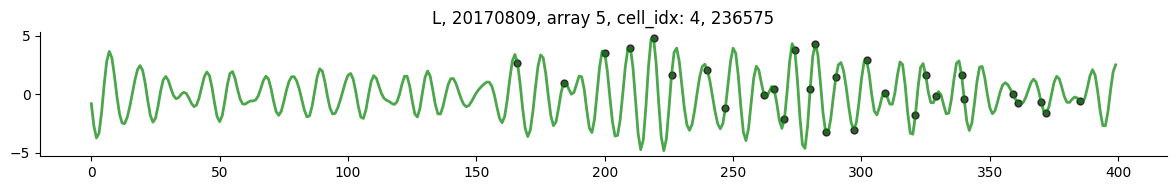

In [84]:
for spike in spikes_leading:
    if spike==236575:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Green 2

In [85]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 5
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 4
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170809
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_medium_shallow
3 DOWN_narrow_sharp
4 UP
5 DOWN_wide
6 DOWN_medium_shallow
7 DOWN_medium_shallow
8 DOWN_medium_sharp
9 DOWN_medium_shallow
10 DOWN_medium_shallow
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 DOWN_wide
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_medium_shallow
19 DOWN_medium_shallow
20 DOWN_medium_shallow
Num. cells: 21
Cell idx: 4, UP, channel: 20


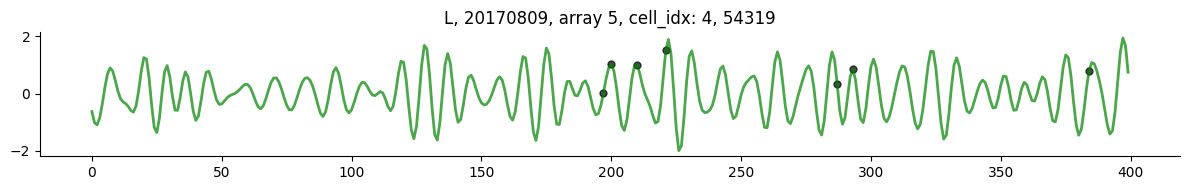

In [86]:
for spike in spikes_leading:
    if spike==54319:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Orange 1

In [91]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 16
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170725
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_medium_sharp
3 DOWN_medium_sharp
4 DOWN_medium_sharp
5 DOWN_medium_sharp
6 DOWN_wide
7 DOWN_wide
8 DOWN_wide
9 UP
10 DOWN_medium_sharp
11 DOWN_medium_sharp
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_narrow_sharp
19 DOWN_wide
20 DOWN_medium_sharp
21 DOWN_narrow_sharp
22 DOWN_wide
23 DOWN_medium_sharp
24 DOWN_wide
25 DOWN_narrow_sharp
26 DOWN_narrow_sharp
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
Num. cells: 31
Cell idx: 16, DOWN_medium_shallow, channel: 30


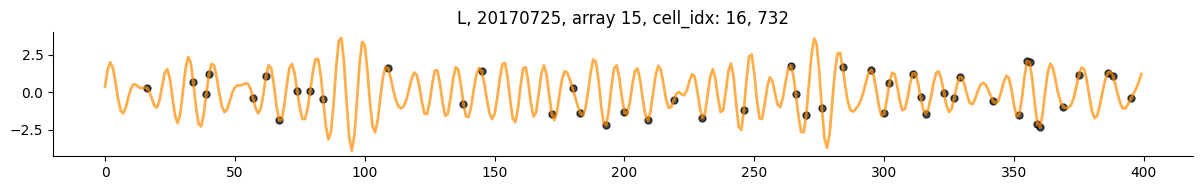

In [92]:
for spike in spikes_leading:
    if spike==732:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Orange 2

In [93]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

cell_idx = 17
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

20170725
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_medium_sharp
3 DOWN_medium_sharp
4 DOWN_medium_sharp
5 DOWN_medium_sharp
6 DOWN_wide
7 DOWN_wide
8 DOWN_wide
9 UP
10 DOWN_medium_sharp
11 DOWN_medium_sharp
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_narrow_sharp
19 DOWN_wide
20 DOWN_medium_sharp
21 DOWN_narrow_sharp
22 DOWN_wide
23 DOWN_medium_sharp
24 DOWN_wide
25 DOWN_narrow_sharp
26 DOWN_narrow_sharp
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
Num. cells: 31
Cell idx: 17, DOWN_medium_shallow, channel: 29


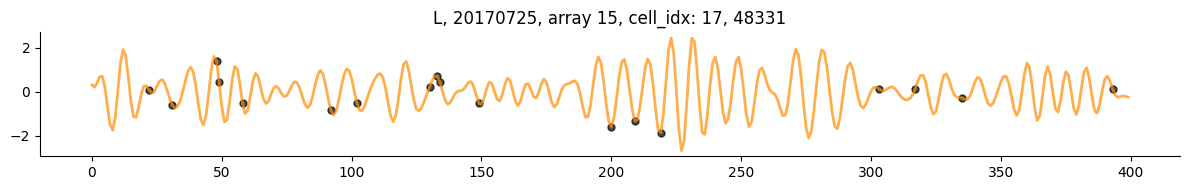

In [94]:
for spike in spikes_leading:
    if spike==48331:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()